# 🏥 Insurance Policy Wording Extractor
**PyMuPDF · Modular Pipeline · RAG-Ready**

This notebook walks through:
1. Installation & setup
2. Upload your own PDF (or use the sample HDFC Ergo policy)
3. Run the extraction pipeline
4. Inspect chunk quality & statistics
5. RAG query demo (no API key needed — pure retrieval)

---

## 0 · Setup

In [1]:
# ── Install dependencies ──────────────────────────────────────────────────
!pip install pymupdf --quiet
!pip install sentence-transformers chromadb --quiet   # for RAG section
print('✅ Dependencies installed')


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Dependencies installed


In [1]:
# ── Clone your repo (replace with your GitHub URL after pushing) ──────────
# !git clone https://github.com/YOUR_USERNAME/insurance_rag.git
# %cd insurance_rag

# ── If running locally / already in the project folder ───────────────────
import sys, os
sys.path.insert(0, '/Users/R/Projects/Insurance-RAG/src')   # make insurance_rag importable
# print(os.getcwd())

from insurance_rag.pipeline       import ExtractionPipeline
from insurance_rag.extractor      import PDFExtractor
from insurance_rag.reconstructor  import SectionReconstructor
from insurance_rag.chunker        import Chunker
from insurance_rag.cleaner        import clean_block_text

print('✅ Package imported')

✅ Package imported


---
## 1 · Load a PDF
Two options — run whichever applies to you.

In [ ]:
# ── Option A: Upload your own PDF ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()           # opens file picker
PDF_PATH = list(uploaded.keys())[0]
print(f'Using: {PDF_PATH}')

In [216]:
# ── Option B: Download the sample HDFC Ergo Optima Secure policy ──────────
import urllib.request

SAMPLE_URL = (
    'https://customer-portal-assets.hdfcergo.com/assets/v2/docs/'
    'default-source/downloads/policy-wordings/health/'
    'optima-secure-revision/optima-secure-revision-pw-647504209314.pdf'
)
PDF_PATH = 'optima-secure.pdf'

print('Downloading …')
urllib.request.urlretrieve(SAMPLE_URL, PDF_PATH)
print(f'✅ Saved to {PDF_PATH}  ({os.path.getsize(PDF_PATH) // 1024} KB)')

✅ Saved to optima-secure.pdf  (610 KB)


In [278]:
# ── Option B: Download the sample Care Supreme policy ──────────
# import urllib.request

# SAMPLE_URL = (
#     'https://cms.careinsurance.com/cms/public/uploads/download_center/care-supreme---policy-terms-&-conditions-(effective-from-19-march-2025).pdf?rv=0.86869200%201775054695'
# )
PDF_PATH = 'care-supreme.pdf'

# print('Downloading …')
# urllib.request.urlretrieve(SAMPLE_URL, PDF_PATH)
# print(f'✅ Saved to {PDF_PATH}  ({os.path.getsize(PDF_PATH) // 1024} KB)')

---
## 2 · Extraction Pipeline Walkthrough
We run each phase separately so you can inspect what's happening at every step.

### 2a · Phase 1 — Raw block extraction

In [306]:
import importlib

# Import the modules
from insurance_rag import pipeline, extractor, reconstructor, chunker, cleaner, models, patterns

# Reload the modules to reflect any code changes
importlib.reload(patterns)
importlib.reload(models)
importlib.reload(pipeline)
importlib.reload(extractor)
importlib.reload(reconstructor)
importlib.reload(chunker)
importlib.reload(cleaner)
# Import the specific classes/functions after reload
from insurance_rag.pipeline import ExtractionPipeline
from insurance_rag.extractor import PDFExtractor
from insurance_rag.reconstructor import SectionReconstructor
from insurance_rag.chunker import Chunker
from insurance_rag.cleaner import clean_block_text

print("Modules reloaded successfully!")

Modules reloaded successfully!


In [307]:
with PDFExtractor(PDF_PATH) as ext:
    raw_blocks = ext.extract_blocks()
    doc_meta   = ext.get_document_metadata()
    toc        = ext.get_toc()

print('Document metadata')
for k, v in doc_meta.items():
    print(f'  {k:15}: {v}')

print(f'\nTotal blocks extracted : {len(raw_blocks)}')
print(f'TOC entries            : {len(toc)}')

Document metadata
  title          : CARE SUPREME KYPB - A5 (2).cdr
  author         : Amit Pandey
  subject        : 
  creator        : CorelDRAW X8
  page_count     : 83
  source_file    : care-supreme.pdf

Total blocks extracted : 1654
TOC entries            : 99


In [308]:
# ── Inspect block type distribution ──────────────────────────────────────
from collections import Counter

type_counts = Counter(b.block_type for b in raw_blocks)
print('Block types:')
for btype, count in type_counts.most_common():
    bar = '█' * (count // 10)
    print(f'  {btype:10} {count:4}  {bar}')

Block types:
  text       1054  █████████████████████████████████████████████████████████████████████████████████████████████████████████
  footer      256  █████████████████████████
  subheading  176  █████████████████
  header      151  ███████████████
  heading      17  █


In [310]:
# ── Inspect a few raw blocks from a specific page ─────────────────────────
PAGE_TO_INSPECT = 4   # change this

page_blocks = [b for b in raw_blocks if b.page_num == PAGE_TO_INSPECT]
print(f'Blocks on page {PAGE_TO_INSPECT}:')
for b in page_blocks[:10]:
    preview = b.text[:80].replace('\n', ' ')
    print(f'  [{b.block_type:8}] font={b.font_size:.1f} bold={b.is_bold}  "{preview}"')

Blocks on page 4:
  [header  ] font=11.0 bold=False  "daycare basis without in-patient services and must comply with all the  followin"
  [text    ] font=11.0 bold=True  "I. Having qualified registered AYUSH Medical Practitioner(s) in charge;"
  [text    ] font=11.0 bold=True  "ii. Having dedicated AYUSH therapy sections as required and/or has equipped oper"
  [text    ] font=11.0 bold=True  "iii. Maintaining daily records of the patients and making them accessible"
  [text    ] font=11.0 bold=False  "to the insurance Company's authorized representative."
  [subheading] font=11.0 bold=True  "2.1.4. Cashless Facility"
  [text    ] font=11.0 bold=True  "means a facility extended by the insurer to the Insured"
  [text    ] font=11.0 bold=False  "where the payments, of the costs of treatment undergone by the insured in  accor"
  [subheading] font=11.0 bold=True  "2.1.5. Condition Precedent"
  [text    ] font=11.0 bold=True  "shall mean a Policy term or condition upon which"


In [311]:
# ── See what cleaning does to a single block ──────────────────────────────
sample_block = raw_blocks[5]   # pick any block index

print('--- RAW ---')
print(repr(sample_block.text))
print('\n--- CLEANED ---')
print(repr(clean_block_text(sample_block.text)))

--- RAW ---
'In consideration of the premium paid by the Policy Holder, subject to the terms &\nconditions contained herein, the Company agrees to pay/indemnify the Insured \nPerson(s), the amount of such expenses that are reasonably and necessarily \nincurred up to the limits specified against respective Benefit in any Policy Year.'

--- CLEANED ---
'In consideration of the premium paid by the Policy Holder, subject to the terms &\nconditions contained herein, the Company agrees to pay/indemnify the Insured \nPerson(s), the amount of such expenses that are reasonably and necessarily \nincurred up to the limits specified against respective Benefit in any Policy Year.'


### 2b · Phase 2 — Section reconstruction

In [312]:
reconstructor = SectionReconstructor()
sections      = reconstructor.reconstruct(raw_blocks)

print(f'Sections found: {len(sections)}\n')

print(f'{"#":>3}  {"Section (Parent)":<25} | {"Heading/Term":<30} | {"Pages":<12} | {"Chars"}')
print('-' * 85)
for i, s in enumerate(sections):
    # Use sub_section if available, otherwise a snippet of the heading
    sub = s["sub_section"]
    pages = f"{min(s['pages'])}–{max(s['pages'])}"
    print(f'{i:>3}  {s["section"][:25]:<25} | {sub:<30} | {pages:<12} | {len(s["text"])}')

Sections found: 194

  #  Section (Parent)          | Heading/Term                   | Pages        | Chars
-------------------------------------------------------------------------------------
  0  PREAMBLE                  |                                | 1–2          | 2024
  1  2. Definitions            |                                | 3–3          | 0
  2  2. Definitions            | 2.1. Standard Definitions:     | 3–3          | 0
  3  2. Definitions            | 2.1.1.Accidental/ Accident     | 3–3          | 95
  4  2. Definitions            | 2.1.2.AYUSH Hospital           | 3–3          | 1094
  5  2. Definitions            | 2.1.3. AYUSH Day CareCentre    | 3–4          | 381
  6  2. Definitions            | 2.1.4. Cashless Facility       | 4–4          | 284
  7  2. Definitions            | 2.1.5. Condition Precedent     | 4–4          | 111
  8  2. Definitions            | 2.1.6. Congenital Anomaly      | 4–4          | 344
  9  2. Definitions            | 2.1.7. Co-p

In [313]:
# ── Inspect a specific section ────────────────────────────────────────────
SECTION_IDX = 9   # change to any index from the table above

s = sections[SECTION_IDX]
print(f'Section  : {s["section"]}')
print(f'Heading  : {s["heading"]}')
print(f'Pages    : {sorted(s["pages"])}')
print(f'Chars    : {len(s["text"])}')
print()
print(s['text'][:1000])

Section  : 2. Definitions
Heading  : 2.1.7. Co-payment
Pages    : [4]
Chars    : 219

is a cost-sharing requirement under a health insurance
policy that provides that the policyholder/insured will bear a specified 
percentage of the admissible claim amount. A co-payment does not reduce 
the sum insured.



### 2c · Phase 3 — Chunking

In [325]:
import importlib

# Import the modules
from insurance_rag import pipeline, extractor, reconstructor, chunker, cleaner, models

# Reload the modules to reflect any code changes
importlib.reload(models)
importlib.reload(pipeline)
importlib.reload(extractor)
importlib.reload(reconstructor)
importlib.reload(chunker)
importlib.reload(cleaner)
# Import the specific classes/functions after reload
from insurance_rag.pipeline import ExtractionPipeline
from insurance_rag.extractor import PDFExtractor
from insurance_rag.reconstructor import SectionReconstructor
from insurance_rag.chunker import HierarchicalChunker
from insurance_rag.cleaner import clean_block_text

print("Modules reloaded successfully!")

Modules reloaded successfully!


In [326]:
CHUNK_SIZE = 1200   # target chars per chunk — tune this
OVERLAP    = 180    # overlap chars between chunks

chunker = HierarchicalChunker(
    chunk_size  = CHUNK_SIZE,
    chunk_overlap = OVERLAP,
    source_file = PDF_PATH,
)
chunks = chunker.chunk(sections)
# chunks = chunker.merge_short_chunks(chunks, min_chars=CHUNK_SIZE//5)  # merge chunks shorter than min chars

print(f'Total chunks: {len(chunks)}')
print(f'Avg chars   : {sum(len(c.text) for c in chunks) // len(chunks)}')
print(f'Avg tokens  : ~{sum(c.token_estimate for c in chunks) // len(chunks)}')

Total chunks: 180
Avg chars   : 709
Avg tokens  : ~177


---
## 3 · Chunk Quality Inspection

In [143]:
!pip install matplotlib --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


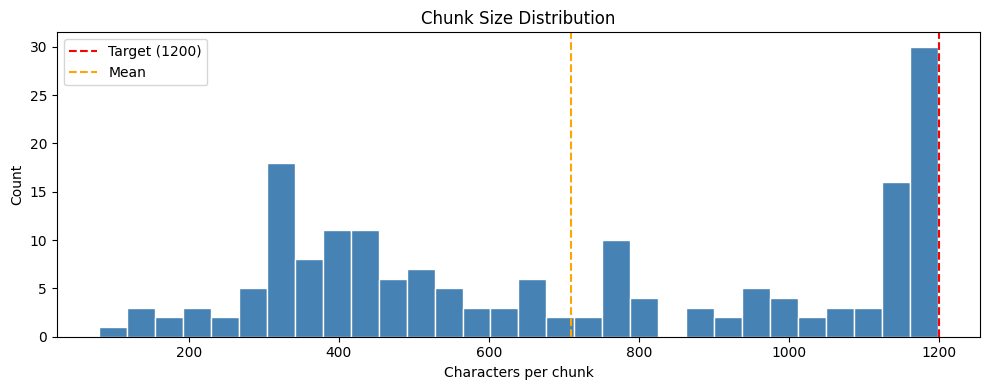

Min: 80  Max: 1199  Mean: 709


In [327]:
# ── Size distribution ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

char_counts = [len(c.text) for c in chunks]

plt.figure(figsize=(10, 4))
plt.hist(char_counts, bins=30, color='steelblue', edgecolor='white')
plt.axvline(CHUNK_SIZE, color='red',    linestyle='--', label=f'Target ({CHUNK_SIZE})')
plt.axvline(sum(char_counts)/len(char_counts), color='orange', linestyle='--', label='Mean')
plt.xlabel('Characters per chunk')
plt.ylabel('Count')
plt.title('Chunk Size Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Min: {min(char_counts)}  Max: {max(char_counts)}  Mean: {sum(char_counts)//len(char_counts)}')

In [328]:
# ── Section coverage ──────────────────────────────────────────────────────
from collections import Counter

section_counts = Counter(c.section for c in chunks)
print(f'{"Section":<45}  {"Chunks"}')
print('-' * 55)
for section, count in section_counts.most_common(15):
    bar = '█' * count
    print(f'{section[:45]:<45}  {count:3}  {bar}')

Section                                        Chunks
-------------------------------------------------------
2. Definitions                                  47  ███████████████████████████████████████████████
6. OTHER TERMS AND CLAUSES                      43  ███████████████████████████████████████████
3. Benefits Covered Under The Policy:           40  ████████████████████████████████████████
5. General Terms And Clauses                    23  ███████████████████████
15. Maternity: (Code Excl18)                     7  ███████
4. Exclusions                                    5  █████
PREAMBLE                                         2  ██
8. Excluded Providers: (Code- Excl11)            2  ██
14. Sterility and Infertility: (Code- Excl17)    2  ██
1. Investigation & Evaluation: (Code- Excl04)    1  █
2. Rest Cure, rehabilitation and respite care    1  █
3. Obesity/ Weight Control: (Code- Excl06)       1  █
4. Change-of-Gender treatments: (Code- Excl07    1  █
5. Cosmetic or plastic Sur

In [329]:
# ── Flag counts — useful for checking table / list detection ──────────────
has_table = sum(1 for c in chunks if c.metadata['has_table'])
has_list  = sum(1 for c in chunks if c.metadata['has_list'])
print(f'Chunks with detected tables  : {has_table}')
print(f'Chunks with detected lists   : {has_list}')

Chunks with detected tables  : 39
Chunks with detected lists   : 68


In [330]:
# ── Inspect any chunk ─────────────────────────────────────────────────────
CHUNK_IDX = 9   # change this

c = chunks[CHUNK_IDX]
print(f'Chunk ID   : {c.chunk_id}')
print(f'Section    : {c.section}')
print(f'Heading    : {c.heading}')
print(f'Pages      : {c.page_start} – {c.page_end}')
print(f'Tokens ~   : {c.token_estimate}')
print(f'Metadata   : {c.metadata}')
print()
print(c.text)

Chunk ID   : 2_1_10_day_care_treatment_0_25c3e309
Section    : 2. Definitions
Heading    : 2.1.10. Day Care Treatment
Pages      : 5 – 5
Tokens ~   : 109
Metadata   : {'chunk_index': 0, 'total_chunks_in_section': 1, 'char_count': 439, 'has_table': False, 'has_list': False}

[2. Definitions] [2.1.10. Day Care Treatment]
means medical treatment, and/or Surgical
Procedure which is:
a.
undertaken under general or local anesthesia in a Hospital/ Day Care
Centre in less than 24 consecutive hours because of technological
advancement, and
b.
which would have otherwise required a Hospitalization of more than
24 hours.
Treatment normally taken on an out-patient basis is not included in the
scope of this definition.


In [324]:
# ── Flag very short chunks (possible extraction noise) ────────────────────
short_chunks = [c for c in chunks if len(c.text) < 100]
print(f'Chunks under 100 chars: {len(short_chunks)}')
for c in short_chunks[:5]:
    print(f'  [{c.section[:30]}]  "{c.text[:80]}"')

Chunks under 100 chars: 15
  [2. Definitions]  "[2. Definitions] [(d)]
It continues indefinitely;
(e) It recurs or is likely to "
  [2. Definitions]  "[2. Definitions] [2.1.30. Network Provider]
(not applicable for Overseas Travel "
  [2. Definitions]  "[2. Definitions] [2.1.48. Specific waiting period (Named Ailment Waiting Period)"
  [3. Benefits Covered Under The ]  "[3. Benefits Covered Under The Policy:] [(v)Post-Hospitalization Medical Expense"
  [3. Benefits Covered Under The ]  "[3. Benefits Covered Under The Policy:] [1.]
Asthma;"


---
## 4 · Save Chunks to JSON

In [224]:
# ── Run the full pipeline in one call (wraps all 3 phases) ────────────────
result = ExtractionPipeline(
    pdf_path   = PDF_PATH,
    chunk_size = CHUNK_SIZE,
    overlap    = OVERLAP,
).run()

out_path = result.save('data/chunks/policy_chunks.json')
print(f'Saved → {out_path}')

Phase 1/3 — Extracting raw blocks …
           53 pages | 1810 blocks | 0 TOC entries
Phase 2/3 — Reconstructing sections …
           228 sections found
Phase 3/3 — Chunking for RAG …

✅  Done in 2.83s — 241 chunks | ~550 chars avg | ~137 tokens avg
Saved → data/chunks/policy_chunks.json


In [ ]:
# ── Download the JSON (Colab only) ────────────────────────────────────────
from google.colab import files
files.download('data/chunks/policy_chunks.json')

---
## 5 · RAG Query Demo
Pure retrieval — no LLM API key needed. Uses sentence-transformers + ChromaDB.

In [225]:
import chromadb
from chromadb.utils import embedding_functions

# ── Build ChromaDB collection ─────────────────────────────────────────────
client = chromadb.Client()   # in-memory for the demo

emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name='all-MiniLM-L6-v2'
)

collection = client.get_or_create_collection(
    name='insurance_policy',
    embedding_function=emb_fn,
)

# Upsert in batches of 100
BATCH = 100
for i in range(0, len(chunks), BATCH):
    batch = chunks[i: i + BATCH]
    collection.upsert(
        ids       = [c.chunk_id for c in batch],
        documents = [c.text     for c in batch],
        metadatas = [{
            'section'   : c.section,
            'heading'   : c.heading[:100],
            'page_start': c.page_start,
            'page_end'  : c.page_end,
            'has_table' : str(c.metadata['has_table']),
        } for c in batch],
    )

print(f'✅ ChromaDB collection ready — {collection.count()} documents')

/Users/R/Projects/Insurance-RAG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


KeyboardInterrupt: 

In [ ]:
def retrieve(query: str, n: int = 3, section_filter: str = None):
    """
    Retrieve top-n chunks for a query.
    Optionally restrict to chunks whose section contains section_filter.
    """
    where = None
    if section_filter:
        # ChromaDB where filter — exact match on the stored section string
        # For partial match, post-filter after retrieval (see cell below)
        pass

    results = collection.query(
        query_texts = [query],
        n_results   = n,
        include     = ['documents', 'metadatas', 'distances'],
    )

    docs      = results['documents'][0]
    metadatas = results['metadatas'][0]
    distances = results['distances'][0]

    # Post-filter by section keyword if provided
    if section_filter:
        filtered = [
            (d, m, dist) for d, m, dist in zip(docs, metadatas, distances)
            if section_filter.lower() in m['section'].lower()
        ]
        docs, metadatas, distances = zip(*filtered) if filtered else ([], [], [])

    return list(zip(docs, metadatas, distances))


def print_results(query, results):
    print(f'Query: "{query}"')
    print('─' * 70)
    for i, (doc, meta, dist) in enumerate(results):
        score = round(1 - dist, 3)
        print(f'\n[{i+1}] Section : {meta["section"]}')
        print(f'    Heading : {meta["heading"][:60]}')
        print(f'    Pages   : {meta["page_start"]}–{meta["page_end"]}')
        print(f'    Score   : {score}')
        print(f'    Text    : {doc[:300].replace(chr(10), " ")} …')

In [ ]:
# ── Try any insurance query ───────────────────────────────────────────────
QUERIES = [
    'What is the waiting period for pre-existing diseases?',
    'Is maternity benefit covered?',
    'What are the room rent sub-limits?',
    'How do I file a cashless claim?',
    'What conditions are excluded from coverage?',
]

for q in QUERIES:
    results = retrieve(q, n=2)
    print_results(q, results)
    print('\n' + '=' * 70 + '\n')

In [ ]:
# ── Section-filtered retrieval ────────────────────────────────────────────
# Only retrieve from chunks whose section contains 'EXCLUSION'

results = retrieve(
    'pre-existing disease',
    n=5,
    section_filter='EXCLUSION'
)
print_results('pre-existing disease  [filtered: EXCLUSION sections only]', results)

In [ ]:
# ── Your own query ────────────────────────────────────────────────────────
MY_QUERY = 'your question here'

results = retrieve(MY_QUERY, n=3)
print_results(MY_QUERY, results)